# Clouds Everywhere — Demo 2
**Ask a simple question:** *for my area, my dates, and my cloud limit — is imagery available, and where are the data gaps?*

This demo focuses on the friendly `query()` function, then drops down to the expert views (heatmaps, timelines, maps).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

from aoi import to_bbox
from query import query
from coverage import check_coverage
from viz import (
    plot_availability_calendar,
    plot_coverage_heatmap,
    plot_cloud_timeline,
    plot_satellite_comparison,
)
import pandas as pd

print('Library loaded.')

Library loaded.


## 1. Define your study area — any format works

A plain bbox, a polygon ring, or a GeoJSON dict all normalise to the same WGS84 bbox.

In [2]:
aoi_bbox = [-4.5, 39.5, -2.5, 41.0]                        # Madrid region
aoi_ring = [[-4.5,39.5],[-2.5,39.5],[-2.5,41.0],[-4.5,41.0],[-4.5,39.5]]
aoi_geojson = {'type':'Feature','properties':{},
    'geometry':{'type':'Polygon','coordinates':[aoi_ring]}}

for name, aoi in [('bbox', aoi_bbox), ('ring', aoi_ring), ('GeoJSON', aoi_geojson)]:
    print(f'{name:8s} -> {to_bbox(aoi)}')

aoi = aoi_geojson

bbox     -> [-4.5, 39.5, -2.5, 41.0]
ring     -> [-4.5, 39.5, -2.5, 41.0]
GeoJSON  -> [-4.5, 39.5, -2.5, 41.0]


## 2. The availability query  ⭐

Pick your **cloud threshold**, **dates**, **study area**, and how to **group** the
results (`day` / `week` / `month`). The report tells you, in plain language:

- how many tiles are needed to cover your area
- for each period, whether imagery is **available**, has a **gap**, or is **missing**
- exactly which tiles are the holes

In [3]:
report = query(
    aoi,
    start_date = '2024-01-01',
    end_date   = '2024-02-29',
    max_cloud  = 20,
    group_by   = 'week',
    satellites = ['sentinel2'],
)

print(report)          # friendly, plain-language summary

  SATELLITE DATA AVAILABILITY REPORT
  Study area (bbox) : [-4.5, 39.5, -2.5, 41.0]
  Date range        : 2024-01-01  ->  2024-02-29
  Cloud threshold   : <= 20%
  Grouped by        : week

--------------------------------------------------------------------
  Sentinel-2  -  needs 9 tiles to fully cover your area
--------------------------------------------------------------------
    [GAP] 1-7 Jan 2024           Data gap - some tiles missing  (6/9 tiles; missing: 30SWJ, 30TWK, 30TWL)
    [OK]  8-14 Jan 2024          All tiles have usable imagery  (15 images across 9 tiles)
    [GAP] 15-21 Jan 2024         Data gap - some tiles missing  (3/9 tiles; missing: 30SVJ, 30SWJ, 30TUL, 30TVL, 30TWK, 30TWL)
    [GAP] 22-28 Jan 2024         Data gap - some tiles missing  (2/9 tiles; missing: 30SUJ, 30SVJ, 30SWJ, 30TVK, 30TVL, 30TWK, +1 more)
    [OK]  29 Jan-04 Feb 2024     All tiles have usable imagery  (13 images across 9 tiles)
    [--]  5-11 Feb 2024          No usable imagery
    [OK]  12-1

## 3. Same result as a table

For filtering, sorting, or exporting to CSV.

In [4]:
report.to_dataframe()

,Period,Start,Satellite,Status,Tiles needed,Tiles covered,Images,Missing tiles
0,1-7 Jan 2024,2024-01-01,Sentinel-2,gap,9,6,8,"30SWJ, 30TWK, 30TWL"
1,8-14 Jan 2024,2024-01-08,Sentinel-2,available,9,9,15,-
2,15-21 Jan 2024,2024-01-15,Sentinel-2,gap,9,3,3,"30SVJ, 30SWJ, 30TUL, 30TVL, 30TWK, 30TWL"
3,22-28 Jan 2024,2024-01-22,Sentinel-2,gap,9,2,2,"30SUJ, 30SVJ, 30SWJ, 30TVK, 30TVL, 30TWK, 30TWL"
4,29 Jan-04 Feb 2024,2024-01-29,Sentinel-2,available,9,9,13,-
5,5-11 Feb 2024,2024-02-05,Sentinel-2,missing,9,0,0,"30SUJ, 30SVJ, 30SWJ, 30TUK, 30TUL, 30TVK, 30TV..."
6,12-18 Feb 2024,2024-02-12,Sentinel-2,available,9,9,9,-
7,19-25 Feb 2024,2024-02-19,Sentinel-2,gap,9,6,7,"30SWJ, 30TWK, 30TWL"
8,26 Feb-03 Mar 2024,2024-02-26,Sentinel-2,gap,9,3,3,"30SWJ, 30TUL, 30TVK, 30TVL, 30TWK, 30TWL"


## 4. Availability calendar

One glance: green = available, amber = gap, red = missing. The number shows covered / needed tiles.

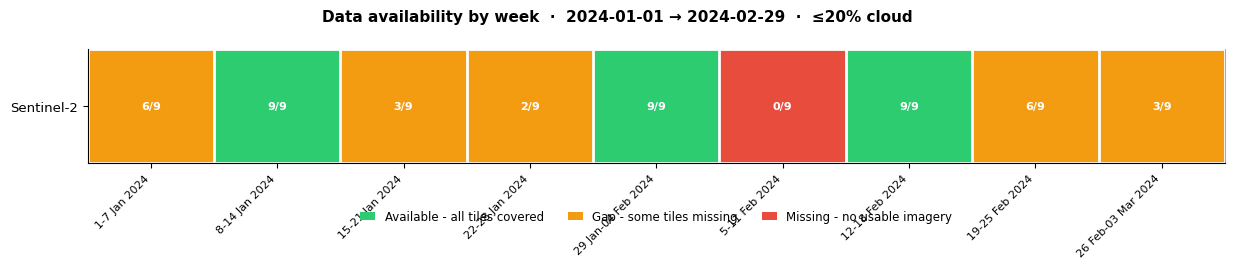

In [5]:
fig = plot_availability_calendar(report)

## 5. Zoom out — group by month, compare satellites

Same question, monthly buckets, Sentinel-2 vs Landsat side by side.

In [6]:
monthly = query(
    aoi,
    '2024-01-01', '2024-06-30',
    max_cloud = 20,
    group_by  = 'month',
    satellites = ['sentinel2', 'landsat'],
)
fig = plot_availability_calendar(monthly)

In [7]:
monthly.to_dataframe()

,Period,Start,Satellite,Status,Tiles needed,Tiles covered,Images,Missing tiles
0,January 2024,2024-01-01,Sentinel-2,available,9,9,32,-
1,January 2024,2024-01-01,landsat-8,gap,9,2,2,"P200R031, P200R032, P200R033, P201R031, P201R0..."
2,January 2024,2024-01-01,landsat-9,gap,9,4,5,"P200R031, P200R032, P201R031, P201R032, P201R033"
3,February 2024,2024-02-01,Sentinel-2,available,9,9,28,-
4,February 2024,2024-02-01,landsat-8,missing,9,0,0,"P200R031, P200R032, P200R033, P201R031, P201R0..."
5,February 2024,2024-02-01,landsat-9,gap,9,1,1,"P200R031, P200R032, P200R033, P201R031, P201R0..."
6,March 2024,2024-03-01,Sentinel-2,gap,9,6,14,"30TUL, 30TWK, 30TWL"
7,March 2024,2024-03-01,landsat-8,gap,9,1,1,"P200R032, P200R033, P201R031, P201R032, P201R0..."
8,March 2024,2024-03-01,landsat-9,gap,9,3,3,"P200R031, P200R032, P200R033, P201R031, P202R0..."
9,April 2024,2024-04-01,Sentinel-2,available,9,9,38,-


## 6. How strict should your cloud limit be?

Tighten the threshold and watch how many weeks stay fully available.

In [8]:
for threshold in [10, 20, 40]:
    r = query(aoi, '2024-01-01', '2024-02-29',
              max_cloud=threshold, group_by='week', satellites=['sentinel2'])
    n_ok  = len(r.available_periods())
    n_gap = len(r.gap_periods())
    total = len({p.period_start for p in r.periods})
    print(f'  <= {threshold:3d}% cloud  ->  {n_ok} fully available, {n_gap} with gaps  (of {total} weeks)')

  <=  10% cloud  ->  1 fully available, 7 with gaps  (of 9 weeks)


  <=  20% cloud  ->  3 fully available, 5 with gaps  (of 9 weeks)


  <=  40% cloud  ->  3 fully available, 5 with gaps  (of 9 weeks)


## 7. Which tiles are the holes?

Drill into the per-tile detail to see exactly where imagery is thin.

In [9]:
tiles = report.tile_dataframe()
# tiles with the fewest usable images across the whole range
(tiles.groupby('Tile')['Usable'].sum()
      .sort_values()
      .rename('Total usable images')
      .reset_index())

,Tile,Total usable images
0,30SWJ,3
1,30TWK,3
2,30TWL,3
3,30SVJ,8
4,30TVL,8
5,30TVK,8
6,30SUJ,8
7,30TUK,9
8,30TUL,10


## 8. Different region — Nile Delta, Egypt

Same one-line query, completely different geography.

In [10]:
nile_delta = {'type':'Feature','properties':{},
    'geometry':{'type':'Polygon','coordinates':[[
        [30.0,30.0],[32.5,30.0],[32.5,31.5],[30.0,31.5],[30.0,30.0]]]}}

nile_report = query(
    nile_delta,
    '2024-01-01', '2024-02-29',
    max_cloud = 20,
    group_by  = 'week',
    satellites = ['sentinel2'],
)
print(nile_report)

  SATELLITE DATA AVAILABILITY REPORT
  Study area (bbox) : [30.0, 30.0, 32.5, 31.5]
  Date range        : 2024-01-01  ->  2024-02-29
  Cloud threshold   : <= 20%
  Grouped by        : week

--------------------------------------------------------------------
  Sentinel-2  -  needs 8 tiles to fully cover your area
--------------------------------------------------------------------
    [GAP] 1-7 Jan 2024           Data gap - some tiles missing  (7/8 tiles; missing: 36RVV)
    [GAP] 8-14 Jan 2024          Data gap - some tiles missing  (7/8 tiles; missing: 35RQQ)
    [GAP] 15-21 Jan 2024         Data gap - some tiles missing  (6/8 tiles; missing: 36RVU, 36RVV)
    [GAP] 22-28 Jan 2024         Data gap - some tiles missing  (2/8 tiles; missing: 35RQP, 35RQQ, 36RTU, 36RTV, 36RUV, 36RVV)
    [GAP] 29 Jan-04 Feb 2024     Data gap - some tiles missing  (1/8 tiles; missing: 35RQP, 35RQQ, 36RTU, 36RTV, 36RUU, 36RVU, +1 more)
    [OK]  5-11 Feb 2024          All tiles have usable imagery  (10 im

In [11]:
fig = plot_availability_calendar(nile_report)

## 9. Expert views

For power users: the underlying tile-level coverage as a heatmap, a cloud
timeline, and a satellite comparison. These use `check_coverage()` directly.

In [12]:
cov = check_coverage(aoi, '2024-01-01', '2024-03-31', max_cloud=20)
fig = plot_coverage_heatmap(cov, max_cloud=20, satellite='Sentinel-2')

In [13]:
fig = plot_cloud_timeline(cov, max_cloud=20, satellite='Sentinel-2')

In [14]:
fig = plot_satellite_comparison(cov, max_cloud=20)

## 10. Interactive spatial tile map

Where the tiles physically sit, coloured by how often they are usable.

In [15]:
import folium
from collections import defaultdict

tile_stats = defaultdict(lambda: {'clouds': [], 'geometry': None})
for c in cov:
    for tr in c.tile_details:
        ts = tile_stats[tr.tile_id]
        if tr.geometry and ts['geometry'] is None:
            ts['geometry'] = tr.geometry
        if tr.cloud_cover != -1:
            ts['clouds'].append(tr.cloud_cover)

def tile_color(clouds, threshold):
    if not clouds: return '#95a5a6'
    usable = sum(1 for c in clouds if c <= threshold) / len(clouds)
    if usable >= 0.6: return '#2ecc71'
    if usable >= 0.3: return '#f39c12'
    if usable  > 0:   return '#e74c3c'
    return '#95a5a6'

aoi_b = to_bbox(aoi)
m = folium.Map(location=[40.0, -3.5], zoom_start=7, tiles='CartoDB positron')
folium.Rectangle(
    bounds=[[aoi_b[1], aoi_b[0]], [aoi_b[3], aoi_b[2]]],
    color='#2980b9', weight=2.5, fill=True, fill_opacity=0.08,
    tooltip='Analysis AOI'
).add_to(m)

for tile_id, ts in tile_stats.items():
    if not ts['geometry']: continue
    clouds = ts['clouds']
    color  = tile_color(clouds, 20)
    best   = f'{min(clouds):.1f}' if clouds else 'N/A'
    usable = sum(1 for c in clouds if c <= 20)
    tooltip = (f'<b>Tile {tile_id}</b><br>Best cloud: {best}%<br>'
               f'Usable dates: {usable}/{len(clouds)}')
    folium.GeoJson(ts['geometry'],
        style_function=lambda _, c=color: {
            'fillColor': c, 'color': 'white', 'weight': 1.0, 'fillOpacity': 0.6},
        tooltip=folium.Tooltip(tooltip, sticky=False)).add_to(m)

legend = '''
<div style="position:fixed;bottom:24px;left:24px;z-index:1000;
            background:white;padding:10px 14px;border-radius:8px;
            box-shadow:0 1px 5px rgba(0,0,0,.25);font-size:12px;line-height:1.9">
  <b>Tile usability (% of dates &le;20% cloud)</b><br>
  <span style="background:#2ecc71;padding:2px 12px;border-radius:3px">&nbsp;</span> &ge;60%<br>
  <span style="background:#f39c12;padding:2px 12px;border-radius:3px">&nbsp;</span> 30&ndash;60%<br>
  <span style="background:#e74c3c;padding:2px 12px;border-radius:3px">&nbsp;</span> &lt;30%<br>
  <span style="background:#95a5a6;padding:2px 12px;border-radius:3px">&nbsp;</span> No data
</div>
'''
m.get_root().html.add_child(folium.Element(legend))
m